# Models tabulars clàssics

---

## 1. Introducció i objectius

Aquest notebook entrena i compara models clàssics d'aprenentatge automàtic sobre les característiques tabulars extretes al Capítol 4:

| Model | Justificació |
|---|---|
| Regressió Logística (L1/L2) | Baseline interpretable |
| Random Forest | Robust al desequilibri |
| XGBoost | Estat de l'art tabular |
| SVM (RBF) | Bo en conjunts petits |

El protocol de validació és **Nested CV 5×3 amb 3 llavors**, que es manté com a esquema central
per a la selecció d'hiperparàmetres (la seva separació entre bucle intern i extern evita el biaix
optimista). Per garantir la **coherència metodològica amb el bloc de models basats en
espectrogrames**, però, s'introdueixen tres canvis:

1. La **mètrica de selecció** del millor model és l'**AUC-ROC** (no el F1 ni el F2), i el bucle
   intern de la nested CV també optimitza l'AUC-ROC. És una mètrica independent del llindar i,
   per tant, més estable que el F1 o el F2 quan hi ha tan pocs casos positius.

2. S'afegeix l'**interval de confiança del 95 % per *bootstrap*** sobre les prediccions
   *out-of-fold*, que quantifica la precisió de l'estimació millor que la desviació entre *folds*.
3. S'afegeix un ***permutation test*** per model, que confirma que la separació observada entre
   classes supera l'atzar — la peça que el bloc tabular no incloïa.

El **llindar de decisió** (punt d'operació clínic) es fixa maximitzant el **F2 (β = 2)** sobre
les prediccions *out-of-fold*, no el F1. La raó és l'asimetria clínica de costos: no detectar un
infant dislèxic (fals negatiu) implica que no rebrà atenció professional, mentre que un fals
positiu comporta únicament una exploració addicional innecessària. L'F₂ pondera el *recall*
el doble que la precisió: F₂ = 5·(P·R) / (4·P + R), de manera que el llindar escollit
maximitza la detecció de casos reals sense ignorar completament la precisió.


## 2. Imports i configuració

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import pickle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, roc_curve, auc,
    precision_recall_curve,
)
import xgboost as xgb
import shap

from utils.data_loading import load_dataset
from utils.metrics import compute_metrics, aggregate_metrics, format_metrics
from utils.validation import nested_cv, oof_to_dataframe

sns.set_theme(style="whitegrid", font_scale=1.1)
RANDOM_STATE = 42
SEEDS = [0, 1, 2]
OUTPUTS = Path.cwd() / "outputs"
OUTPUTS.mkdir(exist_ok=True)

print(f"Root: {Path.cwd()}")
print(f"Outputs: {OUTPUTS}")

Root: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection
Outputs: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\outputs


## 3. Càrrega i preparació de les dades

In [2]:
SPLIT_PATH = OUTPUTS / "holdout_split.json"

data = load_dataset(random_state=RANDOM_STATE, split_path=SPLIT_PATH)

X_train = data["X_train"]
y_train = data["y_train"]
X_hold = data["X_hold"]
y_hold = data["y_hold"]
groups_train = data["groups_train"]
groups_hold = data["groups_hold"]
feature_names = data["feature_names"]
df_train = data["df_train"]
df_hold = data["df_hold"]

print(f"Divisió: {data['split_source']} ({SPLIT_PATH})")
print(f"Conjunt d'entrenament: {X_train.shape[0]} mostres")
print(f"Hold-out final:        {X_hold.shape[0]} mostres")
print(f"Features:              {len(feature_names)}")
print(f"\nDistribució y_train → 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"Distribució y_hold  → 0: {(y_hold==0).sum()}, 1: {(y_hold==1).sum()}")
print(f"\nFeatures: {feature_names}")

Divisió: loaded (c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\outputs\holdout_split.json)
Conjunt d'entrenament: 112 mostres
Hold-out final:        29 mostres
Features:              22

Distribució y_train → 0: 102, 1: 10
Distribució y_hold  → 0: 26, 1: 3

Features: ['edat', 't_total', 't_art', 'r_art', 'n_pauses', 'm_pauses', 't_pauses', 'n_correct', 'n_sub', 'n_omis', 'n_add', 'n_err', 'wer_lect', 'acc_lect', 'n_conf', 'f0_mean', 'f0_std', 'int_mean', 'int_std', 'llengua_altres', 'llengua_castellà', 'llengua_català']


### Contracte de divisió train / hold-out

La primera execució d'aquest notebook genera `outputs/holdout_split.json` amb els índexs CSV exactes (fila 0…N-1) de cada partició. A partir d'aquest moment:

- **Notebook 06** (aquest): crida `load_dataset(split_path=SPLIT_PATH)` → genera i desa.
- **Notebook 07** (`07_model_espectrogrames.ipynb`): `load_dataset(split_path=SPLIT_PATH)` → carrega.
- **Notebook 08** (`08_model_hibrid.ipynb`): `load_dataset(split_path=SPLIT_PATH)` → carrega.

D'aquesta manera la divisió és idèntica fins i tot si canvia la versió de scikit-learn o l'ordre de les files del CSV.

## 4. Definició dels models i espais d'hiperparàmetres

Cada model s'encapsula en un `Pipeline(StandardScaler → Classificador)` per evitar fuites de dades durant la validació.

In [3]:
pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()  # per a scale_pos_weight

MODELS = {
    "logreg": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "param_grid": [
            {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1"], "clf__solver": ["liblinear"]},
            {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l2"], "clf__solver": ["lbfgs"]},

        ],
        "search_type": "grid",
        "label": "Regressió Logística",
    },
    "rf": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "param_grid": {
            "clf__n_estimators": [100, 200, 300, 400],
            "clf__max_depth": [None, 4, 6, 8, 10],
            "clf__min_samples_leaf": [1, 2, 4, 6],
        },
        "search_type": "grid",
        "label": "Random Forest",
    },
    "xgb": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", xgb.XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0,
                scale_pos_weight=pos_ratio,
            )),
        ]),
        "param_grid": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 4, 5],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        },
        "search_type": "random",
        "label": "XGBoost",
    },
    "svm": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "param_grid": {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.01, 0.001],
        },
        "search_type": "random",
        "label": "SVM (RBF)",
    },
}

print(f"ràtio classes (neg/pos): {pos_ratio:.2f}")
print("Models definits:", list(MODELS.keys()))

ràtio classes (neg/pos): 10.20
Models definits: ['logreg', 'rf', 'xgb', 'svm']


## 5. Nested Cross-Validation

- **Bucle extern:** `StratifiedKFold(n_splits=5)` × 3 llavors `[0, 1, 2]` — estima el rendiment.
- **Bucle intern:** `StratifiedKFold(n_splits=3)` per a `GridSearchCV` / `RandomizedSearchCV` amb
  `scoring='roc_auc'` — selecciona els hiperparàmetres.

El bucle intern optimitza l'**AUC-ROC** (coherent amb el criteri de selecció del millor model i
amb el bloc espectral). L'IC per *bootstrap* i el *permutation test* s'afegeixen a la secció 6.

⚠️ Cada model pot trigar uns minuts.


In [4]:
all_results = {}

for model_key, model_cfg in MODELS.items():
    print(f"Entrenant {model_cfg['label']}...", end=" ", flush=True)
    result = nested_cv(
        estimator=model_cfg["pipeline"],
        X=X_train,
        y=y_train,
        groups=groups_train,
        param_grid=model_cfg["param_grid"],
        feature_names=feature_names,
        outer_splits=5,
        inner_splits=3,
        seeds=SEEDS,
        scoring="roc_auc",
        search_type=model_cfg["search_type"],
        n_iter=20,
    )
    all_results[model_key] = result
    fmt = format_metrics(result["agg_metrics"])
    print(f"F1={fmt['f1']}  AUC-ROC={fmt['roc_auc']}  Recall={fmt['recall']}")
    
print("\nEntrenament complet.")

Entrenant Regressió Logística... F1=0.564 ± 0.172  AUC-ROC=0.916 ± 0.097  Recall=0.833 ± 0.236
Entrenant Random Forest... F1=0.627 ± 0.108  AUC-ROC=0.891 ± 0.135  Recall=0.667 ± 0.236
Entrenant XGBoost... F1=0.557 ± 0.207  AUC-ROC=0.883 ± 0.128  Recall=0.600 ± 0.271
Entrenant SVM (RBF)... F1=0.256 ± 0.315  AUC-ROC=0.604 ± 0.423  Recall=0.200 ± 0.245

Entrenament complet.


## 6. Comparació de models i anàlisi estadística

A la taula següent es resumeix la nested CV (mitjana ± desviació entre *folds*). Tot seguit
s'afegeix l'anàlisi harmonitzada amb el bloc espectral: AUC-ROC *out-of-fold* amb el seu
interval de confiança del 95 % per *bootstrap* i el *permutation test* de cada model.


In [7]:
# ── Utilitats per a l'anàlisi harmonitzada (IC bootstrap + permutation test) ──
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score

HARMON_CFG = dict(n_splits=5, seeds=[0, 1, 2], n_perm=500,
                  perm_seed=42, boot_n=2000)

def bootstrap_ci(yt, yp, fn, n=2000, seed=0):
    # IC per bootstrap remostrejant subjectes (mateix esquema que el bloc espectral)
    rng = np.random.RandomState(seed)
    yt = np.asarray(yt); yp = np.asarray(yp)
    pt = fn(yt, yp); vals = []; N = len(yt)
    for _ in range(n):
        idx = rng.randint(0, N, N)
        if len(np.unique(yt[idx])) < 2:
            continue
        try:
            vals.append(fn(yt[idx], yp[idx]))
        except ValueError:
            continue
    if not vals:
        return pt, float("nan"), float("nan")
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return pt, float(lo), float(hi)

def cv_oof_auc(pipeline, X, y, n_splits, seeds):
    # AUC OOF amb config fixa i CV simple (per a observat i nul·la del permutation test)
    X = np.asarray(X); y = np.asarray(y); n = len(y)
    p = np.zeros(n); c = np.zeros(n)
    for sd in seeds:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=sd)
        for tr, va in skf.split(X, y):
            est = clone(pipeline); est.fit(X[tr], y[tr])
            p[va] += est.predict_proba(X[va])[:, 1]; c[va] += 1
    oof = p / np.maximum(c, 1)
    return roc_auc_score(y, oof), average_precision_score(y, oof), oof

def permutation_test_model(pipeline, X, y, cfg):
    # Barreja etiquetes i recalcula l'AUC OOF amb el MATEIX estimador (config fixa)
    obs_r, obs_a, _ = cv_oof_auc(pipeline, X, y, cfg["n_splits"], cfg["seeds"])
    rng = np.random.RandomState(cfg["perm_seed"]); yv = np.asarray(y)
    nr = np.empty(cfg["n_perm"]); na = np.empty(cfg["n_perm"])
    for i in range(cfg["n_perm"]):
        yp = rng.permutation(yv)
        r, a, _ = cv_oof_auc(pipeline, X, yp, cfg["n_splits"], cfg["seeds"])
        nr[i] = r; na[i] = a
    p_r = (1 + np.sum(nr >= obs_r)) / (1 + cfg["n_perm"])
    p_a = (1 + np.sum(na >= obs_a)) / (1 + cfg["n_perm"])
    return dict(roc=obs_r, ap=obs_a, p_roc=p_r, p_ap=p_a, null_roc=nr, null_ap=na)

print("Utilitats harmonitzades definides.")


Utilitats harmonitzades definides.


In [8]:
# ── Càlcul per model: AUC-ROC nested CV (selecció) + IC bootstrap OOF + permutation ──
print("Anàlisi harmonitzada — AUC-ROC + IC95 bootstrap + permutation test")
print("=" * 70)
harmon = {}
for key, result in all_results.items():
    _, oof_agg = oof_to_dataframe(result["oof_records"])
    yt = oof_agg["y_true"].values
    yp = oof_agg["prob_dislexia"].values
    # AUC-ROC de la NESTED CV = mètrica de SELECCIÓ (mitjana ± desviació entre folds).
    # És robusta: la desviació gran delata models inestables (vegeu el SVM).
    roc_mean = result["agg_metrics"]["roc_auc"]["mean"]
    roc_std  = result["agg_metrics"]["roc_auc"].get(
        "std", float(np.std([fm["roc_auc"] for fm in result["fold_metrics"]])))
    # IC bootstrap sobre les prediccions OOF agregades (mesura COMPLEMENTÀRIA).
    roc_oof, roc_lo, roc_hi = bootstrap_ci(yt, yp, roc_auc_score, n=HARMON_CFG["boot_n"])
    # Permutation test (config fixa, CV simple).
    perm = permutation_test_model(MODELS[key]["pipeline"], X_train, y_train, HARMON_CFG)
    harmon[key] = dict(roc_mean=roc_mean, roc_std=roc_std,
                       roc_oof=roc_oof, roc_ci=(roc_lo, roc_hi),
                       p_roc=perm["p_roc"], perm_obs=perm["roc"],
                       null_roc=perm["null_roc"], oof_true=yt, oof_prob=yp)
    print(f"  {MODELS[key]['label']:22s} fet")

# ── Taula resum harmonitzada ─────────────────────────────────────
print("\n" + "=" * 100)
print(f"{'Model':22s}  {'AUC-ROC nested (μ±σ)':>22s}  {'AUC-ROC OOF [IC95]':>22s}  {'p (perm)':>9s}")
print("-" * 100)
best_roc = max(harmon[k]["roc_mean"] for k in MODELS)
rows = []
for key in MODELS:
    h = harmon[key]
    nested_str = f"{h['roc_mean']:.3f} ± {h['roc_std']:.3f}"
    oof_str    = f"{h['roc_oof']:.3f} [{h['roc_ci'][0]:.2f},{h['roc_ci'][1]:.2f}]"
    flag = "  <--" if h["roc_mean"] == best_roc else ""
    warn = "  /!\\ inestable" if abs(h["roc_oof"] - h["roc_mean"]) > 0.10 else ""
    print(f"{MODELS[key]['label']:22s}  {nested_str:>22s}  {oof_str:>22s}  {h['p_roc']:9.3f}{flag}{warn}")
    rows.append(dict(model=MODELS[key]["label"], clau=key,
                     auc_roc_nested=h["roc_mean"], auc_roc_nested_std=h["roc_std"],
                     auc_roc_oof=h["roc_oof"], roc_lo=h["roc_ci"][0], roc_hi=h["roc_ci"][1],
                     p_roc=h["p_roc"]))
print("=" * 100)
print("\nLa SELECCIÓ es fa per l'AUC-ROC de la nested CV (μ±σ). Una divergència gran entre")
print("aquesta i l'AUC OOF agregat (marcada /!\\) delata un model INESTABLE: l'OOF agregat")
print("pot semblar alt per artefactes d'escala entre folds, però el model no generalitza.")
pd.DataFrame(rows).to_csv(OUTPUTS / "tabular_harmon_comparison.csv", index=False)
print(f"\nResultats desats a {OUTPUTS / 'tabular_harmon_comparison.csv'}")


Anàlisi harmonitzada — AUC-ROC + IC95 bootstrap + permutation test
  Regressió Logística    fet
  Random Forest          fet
  XGBoost                fet
  SVM (RBF)              fet

Model                     AUC-ROC nested (μ±σ)      AUC-ROC OOF [IC95]   p (perm)
----------------------------------------------------------------------------------------------------
Regressió Logística              0.916 ± 0.097       0.876 [0.74,0.98]      0.002  <--
Random Forest                    0.891 ± 0.135       0.871 [0.71,0.98]      0.002
XGBoost                          0.883 ± 0.128       0.842 [0.68,0.98]      0.004
SVM (RBF)                        0.604 ± 0.423       0.920 [0.84,0.98]      0.010  /!\ inestable

La SELECCIÓ es fa per l'AUC-ROC de la nested CV (μ±σ). Una divergència gran entre
aquesta i l'AUC OOF agregat (marcada /!\) delata un model INESTABLE: l'OOF agregat
pot semblar alt per artefactes d'escala entre folds, però el model no generalitza.

Resultats desats a c:\Users\Marçal\

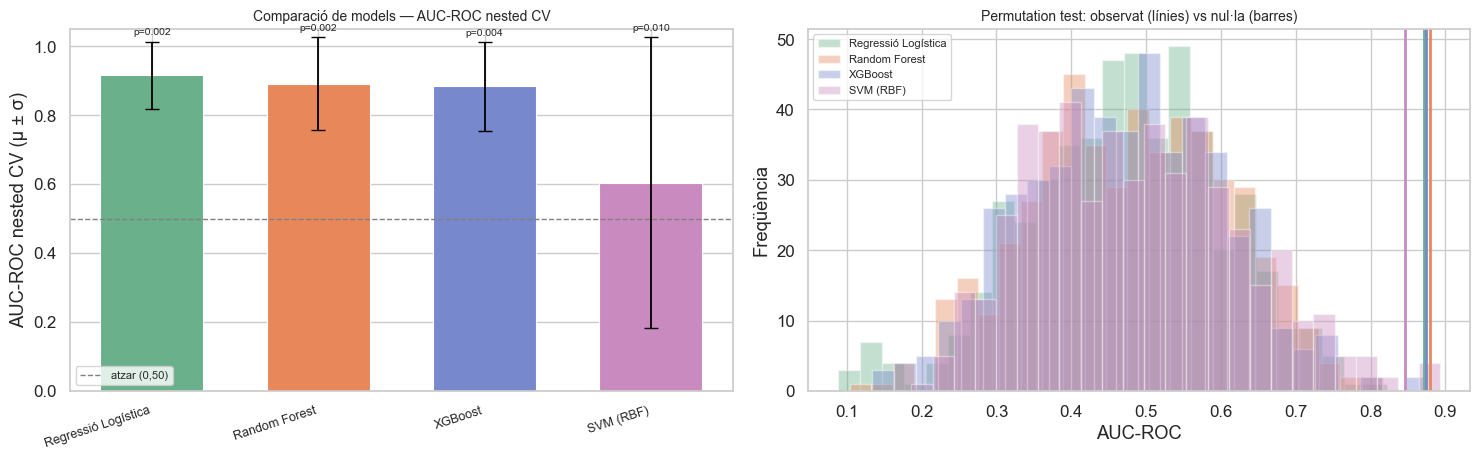

In [9]:
# ── Visualització: AUC-ROC nested CV (μ±σ) + distribucions nul·les ──
import os
os.makedirs("./imatges", exist_ok=True)
_keys = list(MODELS.keys())
_labels = [MODELS[k]["label"] for k in _keys]
_colors = ["#6ab08a", "#e8885a", "#7888cc", "#c98ac0"][:len(_keys)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.8))

xs   = np.arange(len(_keys))
vals = [harmon[k]["roc_mean"] for k in _keys]
errs = [harmon[k]["roc_std"] for k in _keys]
ax1.bar(xs, vals, color=_colors, width=0.62, edgecolor="white", linewidth=0.8)
ax1.errorbar(xs, vals, yerr=errs, fmt="none", ecolor="black", capsize=5, elinewidth=1.3)
ax1.axhline(0.5, ls="--", color="gray", lw=1, label="atzar (0,50)")
ax1.set_xticks(xs); ax1.set_xticklabels(_labels, rotation=18, ha="right", fontsize=9)
ax1.set_ylabel("AUC-ROC nested CV (μ ± σ)")
ax1.set_ylim(0.0, 1.05)
ax1.set_title("Comparació de models — AUC-ROC nested CV", fontsize=10)
ax1.legend(fontsize=8)
for x, k in zip(xs, _keys):
    p = harmon[k]["p_roc"]
    txt = f"p={p:.3f}" if p > 0.001 else "p<0.001"
    ax1.text(x, harmon[k]["roc_mean"] + harmon[k]["roc_std"] + 0.02, txt, ha="center", fontsize=7.5)

for k, col in zip(_keys, _colors):
    ax2.hist(harmon[k]["null_roc"], bins=25, alpha=0.4, color=col, label=MODELS[k]["label"])
    ax2.axvline(harmon[k]["perm_obs"], color=col, lw=2)
ax2.set_xlabel("AUC-ROC"); ax2.set_ylabel("Freqüència")
ax2.set_title("Permutation test: observat (línies) vs nul·la (barres)", fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("./imatges/tabular_auc_comparison.pdf", bbox_inches="tight")
plt.show()


## 7. Anàlisi estadística harmonitzada i selecció del millor model

Es completa l'anàlisi amb les dues mesures que alineen aquest bloc amb el bloc espectral:
l'**IC 95 % per *bootstrap*** sobre les prediccions *out-of-fold* i el ***permutation test***.

La **selecció es fa per l'AUC-ROC de la nested CV** (mitjana entre *folds*), no per l'AUC-ROC
de les prediccions *out-of-fold* agregades. La raó és important i la il·lustra el SVM d'aquest
bloc: amb només 10 positius, l'AUC *out-of-fold* agregat pot inflar-se per artefactes d'escala
entre *folds* (el SVM hi marca 0,92 tot i ser el pitjor model), mentre que la mitjana entre
*folds* —i la seva desviació— delata correctament la inestabilitat (0,60 ± 0,42). La divergència
entre les dues estimacions s'usa, de fet, com a senyal d'alarma. Quan dos models són
indistingibles, s'aplica el **principi de parsimònia**.

El **F2 (β = 2)** s'usa per fixar el **llindar** final sobre les prediccions OOF (secció 7),
no per seleccionar el model. Aquesta distinció és deliberada: la selecció requereix estabilitat
(→ AUC-ROC), mentre que el llindar reflecteix la prioritat clínica de maximitzar la detecció
de casos dislèxics (→ F2, que pondera el *recall* el doble que la precisió).


In [10]:
# Selecció del millor model per AUC-ROC de la NESTED CV (desempat per parsimònia)
# Es fa servir la mitjana entre folds (robusta), NO l'OOF agregat (inestable amb
# pocs positius: pot inflar models degenerats com el SVM fortament regularitzat).
COMPLEXITY = {"logreg": 0, "svm": 1, "rf": 2, "xgb": 3}

best_key = max(MODELS, key=lambda k: (round(harmon[k]["roc_mean"], 3), -COMPLEXITY[k]))
best_roc = harmon[best_key]["roc_mean"]

print(f"Millor model (AUC-ROC nested CV): {MODELS[best_key]['label']}")
print(f"  AUC-ROC = {best_roc:.3f} ± {harmon[best_key]['roc_std']:.3f}  "
      f"p={harmon[best_key]['p_roc']:.3f}")

unstable = [MODELS[k]["label"] for k in MODELS
            if abs(harmon[k]["roc_oof"] - harmon[k]["roc_mean"]) > 0.10]
if unstable:
    print(f"  Models marcats com a inestables (descartats pel criteri robust): {', '.join(unstable)}")


Millor model (AUC-ROC nested CV): Regressió Logística
  AUC-ROC = 0.916 ± 0.097  p=0.002
  Models marcats com a inestables (descartats pel criteri robust): SVM (RBF)


In [11]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

best_cfg = MODELS[best_key]
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

if best_cfg["search_type"] == "random":
    final_search = RandomizedSearchCV(
        best_cfg["pipeline"],
        param_distributions=best_cfg["param_grid"],
        n_iter=30,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
else:
    final_search = GridSearchCV(
        best_cfg["pipeline"],
        param_grid=best_cfg["param_grid"],
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )

final_search.fit(X_train, y_train)
best_model = final_search.best_estimator_
print(f"Millors hiperparàmetres finals: {final_search.best_params_}")

Millors hiperparàmetres finals: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


### Derivació del llindar clínic (F2)

El llindar de decisió s'obté **maximitzant el F₂ sobre les prediccions *out-of-fold*** (mai
sobre les dades d'entrenament directament, per evitar sobreajustament del punt d'operació).

**Per què F₂ i no F₁?**

En el cribratge de dislèxia, les conseqüències d'un **fals negatiu** (infant dislèxic no
detectat) i d'un **fals positiu** (infant típic classificat com a dislèxic) no són simètriques:

- **Fals negatiu** → l'infant no rep atenció professional ni suport educatiu especialitzat.
  L'impacte és greu i difícilment reversible.
- **Fals positiu** → l'infant és derivat a una avaluació addicional que descarta la dislèxia.
  L'impacte és mínim (temps i recursos d'avaluació).

L'F₁ tracta ambdós errors com a equivalents. L'**F₂ (β = 2)** penalitza els falsos negatius
el doble que els falsos positius:

$$F_2 = \frac{5 \cdot \text{Precisió} \cdot \text{Recall}}{4 \cdot \text{Precisió} + \text{Recall}}$$

Això desplaça el llindar cap a valors més baixos, incrementant la sensibilitat a costa d'una
lleugera pèrdua de precisió — exactament el que demana el context clínic.


In [12]:
# Selecció de llindar sobre prediccions OOF (no sobre train directament)
# El model es SELECCIONA per AUC-ROC, però el LLINDAR (punt d'operació clínic) es fixa
# maximitzant el F2 (β=2) sobre les prediccions OOF: recall ponderat 2× sobre precisió.
from sklearn.metrics import fbeta_score

_, oof_agg = oof_to_dataframe(all_results[best_key]["oof_records"])
oof_proba = oof_agg["prob_dislexia"].values
oof_true  = oof_agg["y_true"].values

precisions, recalls, pr_thresholds = precision_recall_curve(oof_true, oof_proba)
# F2 = 5·P·R / (4·P + R)  — exclou el darrer element (sentinel de precision_recall_curve)
f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (4 * precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f2_scores)
best_threshold = pr_thresholds[best_idx]
print(f"Millor llindar (OOF) per maximitzar F2: {best_threshold:.4f} (F2={f2_scores[best_idx]:.4f})")


Millor llindar (OOF) per maximitzar F2: 0.4292 (F2=0.6667)


## 8. Avaluació final sobre el hold-out retingut

In [13]:
# Prediccions del model final sobre el hold-out
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score, recall_score

y_hold_prob = best_model.predict_proba(X_hold)[:, 1]
y_hold_pred = (y_hold_prob >= best_threshold).astype(int)

hold_metrics = {
    "roc_auc":     roc_auc_score(y_hold, y_hold_prob),
    "pr_auc":      average_precision_score(y_hold, y_hold_prob),
    "f1":          f1_score(y_hold, y_hold_pred, zero_division=0),
    "f2":          fbeta_score(y_hold, y_hold_pred, beta=2, zero_division=0),
    "sensibilitat": recall_score(y_hold, y_hold_pred, zero_division=0),
}
print(f"Hold-out  AUC-ROC={hold_metrics['roc_auc']:.3f}  "
      f"AUC-PR={hold_metrics['pr_auc']:.3f}  "
      f"F1={hold_metrics['f1']:.3f}  F2={hold_metrics['f2']:.3f}  "
      f"Sensibilitat={hold_metrics['sensibilitat']:.3f}  "
      f"(llindar={best_threshold:.3f})")


Hold-out  AUC-ROC=0.974  AUC-PR=0.867  F1=0.667  F2=0.667  Sensibilitat=0.667  (llindar=0.429)


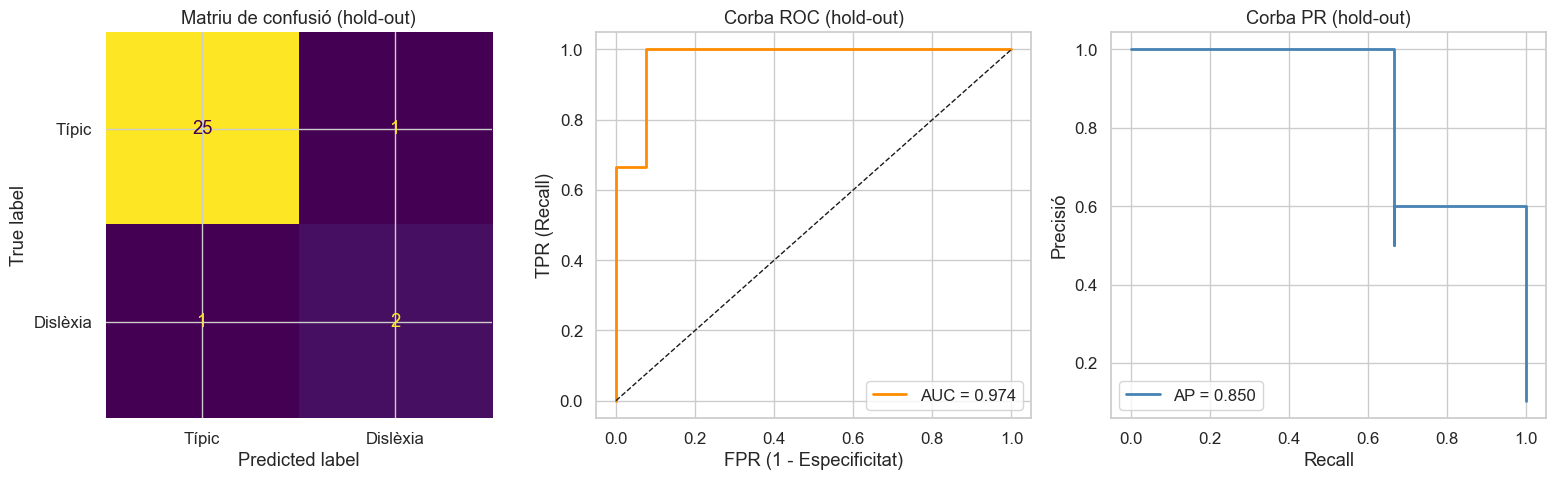

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matriu de confusió
ConfusionMatrixDisplay.from_predictions(
    y_hold, (y_hold_prob >= best_threshold).astype(int),
    display_labels=["Típic", "Dislèxia"],
    colorbar=False, ax=axes[0]
)
# Remove the grid lines from the confusion matrix
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].set_title("Matriu de confusió (hold-out)")

# Corba ROC
fpr, tpr, _ = roc_curve(y_hold, y_hold_prob)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc_val:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("FPR (1 - Especificitat)")
axes[1].set_ylabel("TPR (Recall)")
axes[1].set_title("Corba ROC (hold-out)")
axes[1].legend()

# Corba PR
prec, rec, _ = precision_recall_curve(y_hold, y_hold_prob)
pr_auc_val = auc(rec, prec)
axes[2].step(rec, prec, color="steelblue", lw=2, where="post", label=f"AP = {pr_auc_val:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisió")
axes[2].set_title("Corba PR (hold-out)")
axes[2].legend()

plt.tight_layout()
plt.savefig("./imatges/tabular_holdout_evaluation.pdf", bbox_inches="tight")
plt.show()

In [15]:
# Extreure el classificador i les dades transformades (post-scaler)
scaler = best_model.named_steps["scaler"]
clf = best_model.named_steps["clf"]

X_train_scaled = scaler.transform(X_train)
X_hold_scaled = scaler.transform(X_hold)

clf_name = type(clf).__name__
print(f"Classificador: {clf_name}")

if "XGB" in clf_name or "RandomForest" in clf_name:
    explainer = shap.TreeExplainer(clf)
    raw = explainer.shap_values(X_train_scaled)
else:
    # KernelExplainer per a models sense TreeExplainer (LogReg, SVM, MLP)
    explainer = shap.KernelExplainer(
        clf.predict_proba,
        shap.sample(X_train_scaled, 50),
    )
    raw = explainer.shap_values(X_train_scaled, nsamples=100)

# KernelExplainer i versions antigues de TreeExplainer retornen llista [cls0, cls1]
# Versions noves de SHAP retornen ndarray (n_samples, n_features, n_classes)
if isinstance(raw, list):
    shap_vals = raw[1]          # classe positiva (dislèxia)
elif hasattr(raw, "ndim") and raw.ndim == 3:
    shap_vals = raw[:, :, 1]    # (n_samples, n_features, n_classes) → classe 1
else:
    shap_vals = raw             # (n_samples, n_features) directament

shap_vals = np.array(shap_vals)
print(f"Forma SHAP values: {shap_vals.shape}")

Classificador: LogisticRegression


100%|██████████| 112/112 [00:01<00:00, 58.57it/s]

Forma SHAP values: (112, 22)


## 8.bis Resum consolidat

In [16]:
# ── Resum consolidat de la cadena de decisió del bloc tabular ──
print("=" * 72)
print("   SELECCIÓ DE MODEL — BLOC TABULAR (resum)")
print("=" * 72)
print("\n1) DADES")
print(f"   Train: {X_train.shape[0]} infants ({int((y_train==1).sum())} dislèxia)  |  "
      f"hold-out: {X_hold.shape[0]} ({int((y_hold==1).sum())} dislèxia)")
print(f"   Característiques: {len(feature_names)}")

print("\n2) MODELS  (AUC-ROC nested CV μ±σ; p de permutació; IC OOF complementari)")
for key in MODELS:
    h = harmon[key]; star = "  <-- triat" if key == best_key else ""
    warn = "  /!\\" if abs(h["roc_oof"] - h["roc_mean"]) > 0.10 else ""
    print(f"   {MODELS[key]['label']:22s} AUC-ROC={h['roc_mean']:.3f}±{h['roc_std']:.3f}  "
          f"p={h['p_roc']:.3f}{star}{warn}")

print("\n3) MODEL FINAL")
print(f"   {MODELS[best_key]['label']}  |  hiperparàmetres: {final_search.best_params_}")
print(f"   Llindar (F2 màx. OOF): {best_threshold:.3f}")
print(f"   CV  AUC-ROC = {harmon[best_key]['roc_mean']:.3f} ± {harmon[best_key]['roc_std']:.3f}  "
      f"p={harmon[best_key]['p_roc']:.3f}")
print(f"   Hold-out  AUC-ROC = {hold_metrics['roc_auc']:.3f}  "
      f"AUC-PR = {hold_metrics['pr_auc']:.3f}  "
      f"F1 = {hold_metrics['f1']:.3f}  F2 = {hold_metrics['f2']:.3f}  "
      f"Sensibilitat = {hold_metrics['sensibilitat']:.3f}  "
      f"(llindar={best_threshold:.3f}, n={X_hold.shape[0]}, pos={int((y_hold==1).sum())})")
print("=" * 72)


   SELECCIÓ DE MODEL — BLOC TABULAR (resum)

1) DADES
   Train: 112 infants (10 dislèxia)  |  hold-out: 29 (3 dislèxia)
   Característiques: 22

2) MODELS  (AUC-ROC nested CV μ±σ; p de permutació; IC OOF complementari)
   Regressió Logística    AUC-ROC=0.916±0.097  p=0.002  <-- triat
   Random Forest          AUC-ROC=0.891±0.135  p=0.002
   XGBoost                AUC-ROC=0.883±0.128  p=0.004
   SVM (RBF)              AUC-ROC=0.604±0.423  p=0.010  /!\

3) MODEL FINAL
   Regressió Logística  |  hiperparàmetres: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
   Llindar (F2 màx. OOF): 0.429
   CV  AUC-ROC = 0.916 ± 0.097  p=0.002
   Hold-out  AUC-ROC = 0.974  AUC-PR = 0.867  F1 = 0.667  F2 = 0.667  Sensibilitat = 0.667  (llindar=0.429, n=29, pos=3)


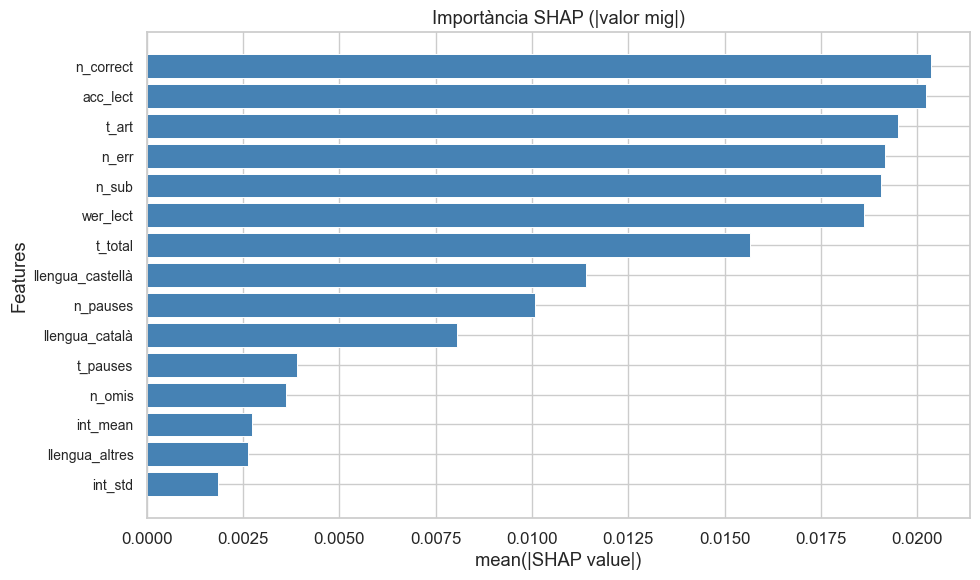

In [17]:
# SHAP importance with aligned feature names
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top_n = 15

# top features sorted (highest first)
idx = np.argsort(mean_abs_shap)[-top_n:]
feat = np.array(feature_names)[idx]
vals = mean_abs_shap[idx]
order = np.argsort(vals)  # for clean bottom->top ordering

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    feat[order],
    vals[order],
    color="steelblue",
    edgecolor="white",
    linewidth=0.7
)

ax.set_title("Importància SHAP (|valor mig|)")
ax.set_xlabel("mean(|SHAP value|)")
ax.set_ylabel("Features")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig("./imatges/tabular_shap.pdf", bbox_inches="tight")
plt.show()


## 9. Exportació model

Model guardat per passos posteriors (models híbrids).

| Fitxer | Ús |
|---|---|
| `tabular_model.pkl` | Model final entrenat sobre tot el conjunt d'entrenament |


In [40]:
with open(OUTPUTS / "tabular_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("Guardat: tabular_model.pkl")

print("\nTots els artefactes exportats correctament.")

Guardat: tabular_model.pkl

Tots els artefactes exportats correctament.
